# Common Test Notebook

## Strategy Discussion

### Model Choice
ResNet-18 was selected as the baseline architecture for several reasons:
- Proven performance on this exact dataset in Alexander et al. (2020), which achieved 
  macro-averaged AUCs of 0.97+ using the same architecture on the same simulation pipeline
- 11.2M parameters — well-matched to the 33,750 training samples without excessive 
  overfitting risk
- Pretrained ImageNet weights provide useful low-level feature detectors (edges, curves, 
  gradients) that transfer well to lensing arc morphology, even from a natural image domain
- The first convolutional layer was adapted from 3-channel to 1-channel input by averaging 
  the pretrained RGB weights, preserving learned edge detectors

### Data Handling
- The provided 80:20 train/val split was recombined and re-split 90:10 per the submission 
  guidelines (33,750 train / 3,750 val), stratified by class
- Float64 arrays were cast to float32 for GPU compatibility with no meaningful precision loss

### Data Augmentation
- Random horizontal/vertical flips and rotations up to 180° were applied during training only
- These augmentations are physically motivated: gravitational lensing images have no 
  preferred orientation on the sky, so all rotations and reflections produce equally valid 
  observations
- Augmentation reduced overfitting significantly — without it, validation loss diverged 
  from training loss after epoch 8

### Training Configuration
- Optimizer: Adam (lr=1e-3, weight_decay=1e-4)
- Scheduler: Cosine annealing over 30 epochs for smooth learning rate decay
- Best model checkpoint saved automatically based on validation loss
- Training completed in ~3.5 minutes on a single NVIDIA H200 GPU

### Results
- Macro-averaged AUC: 0.9940
- Per-class AUC: No Substructure (0.9948), Subhalo (0.9916), Vortex (0.9956)
- Validation accuracy: 95.8%
- Subhalo class shows lowest AUC, consistent with the physics — spherical subhalo 
  perturbations are more localized and subtle compared to vortex string defects
- No substructure class is easiest to identify due to smooth, unperturbed arc morphology

### Baseline for Physics-Guided Extension
This model serves as the baseline for Specific Test VII (Physics-Guided ML), where a 
PINN architecture incorporating the gravitational lensing equation is expected to improve 
upon these results. The current macro AUC of 0.994 provides a strong but beatable 
benchmark for physics-informed approaches.

## 1: Adjusting current split to 90:10

In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split

def get_all_paths(base="dataset"):
    """Collect all file paths and labels, then resplit 90:10."""
    paths, labels = [], []
    class_map = {"no": 0, "sphere": 1, "vort": 2}
    
    for split in ["train", "val"]:
        for cls_name, label in class_map.items():
            d = f"{base}/{split}/{cls_name}"
            for f in os.listdir(d):
                if f.endswith(".npy"):
                    paths.append(os.path.join(d, f))
                    labels.append(label)
    
    # Stratified 90:10 split
    train_paths, val_paths, train_labels, val_labels = train_test_split(
        paths, labels, test_size=0.10, random_state=42, stratify=labels
    )
    
    print(f"Total: {len(paths)}")
    print(f"Train: {len(train_paths)}, Val: {len(val_paths)}")
    return train_paths, train_labels, val_paths, val_labels
    
train_paths, train_labels, val_paths, val_labels = get_all_paths("dataset")

from collections import Counter
print("Train distribution:", Counter(train_labels))
print("Val distribution:",   Counter(val_labels))

Total: 37500
Train: 33750, Val: 3750
Train distribution: Counter({2: 11250, 1: 11250, 0: 11250})
Val distribution: Counter({2: 1250, 0: 1250, 1: 1250})


## 2: Dataset Class and Dataloaders

In [2]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(180),
])

class LensingDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        img = np.load(self.file_paths[idx]).astype(np.float32)
        label = self.labels[idx]
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        return img, label

train_dataset = LensingDataset(train_paths, train_labels, transform=train_transform)
val_dataset   = LensingDataset(val_paths, val_labels, transform=None)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=6, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False,
                          num_workers=6, pin_memory=True, persistent_workers=True)

# Sanity check
imgs, labels = next(iter(train_loader))
print(f"Batch shape: {imgs.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Dtype: {imgs.dtype}")
print(f"Label range: {labels.min()} to {labels.max()}")

Batch shape: torch.Size([64, 1, 150, 150])
Labels shape: torch.Size([64])
Dtype: torch.float32
Label range: 0 to 2


## 3: Model Definition

In [3]:
import torch.nn as nn
import torchvision.models as models

def build_resnet18(num_classes=3):
    # Load ResNet-18 with pretrained ImageNet weights
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    # Modify first conv: 3-channel RGB → 1-channel grayscale
    # Keep the pretrained weights by averaging across the 3 input channels
    old_conv = model.conv1
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    with torch.no_grad():
        model.conv1.weight = nn.Parameter(old_conv.weight.mean(dim=1, keepdim=True))
    
    # Replace final classification layer: 1000 ImageNet classes → 3
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_resnet18(num_classes=3).to(device)

print(f"Device: {device}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Device: cuda
Parameters: 11,171,779


## 4: Training Loop

In [4]:
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
num_epochs = 30
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)  # matches total epochs now

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")

for epoch in range(num_epochs):
    start = time.time()
    
    # === TRAIN ===
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    train_loss = running_loss / total
    train_acc = correct / total
    
    # === VALIDATE ===
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    val_loss = running_loss / total
    val_acc = correct / total
    
    scheduler.step()
    elapsed = time.time() - start
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_resnet18_lensing.pth")
        marker = " ← saved best"
    else:
        marker = ""
    
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
          f"{elapsed:.1f}s{marker}")

# Reload the best weights
model.load_state_dict(torch.load("best_resnet18_lensing.pth"))
print(f"\nTraining complete! Best val loss: {best_val_loss:.4f}")

Epoch  1/30 | Train Loss: 1.1079  Acc: 0.3535 | Val Loss: 1.0029  Acc: 0.4880 | 23.2s ← saved best
Epoch  2/30 | Train Loss: 0.8740  Acc: 0.5615 | Val Loss: 0.6952  Acc: 0.6963 | 7.2s ← saved best
Epoch  3/30 | Train Loss: 0.6220  Acc: 0.7362 | Val Loss: 0.5183  Acc: 0.7835 | 6.7s ← saved best
Epoch  4/30 | Train Loss: 0.4903  Acc: 0.8044 | Val Loss: 0.4741  Acc: 0.8267 | 6.6s ← saved best
Epoch  5/30 | Train Loss: 0.4294  Acc: 0.8301 | Val Loss: 0.4188  Acc: 0.8368 | 6.6s ← saved best
Epoch  6/30 | Train Loss: 0.3934  Acc: 0.8447 | Val Loss: 0.4349  Acc: 0.8371 | 6.6s
Epoch  7/30 | Train Loss: 0.3715  Acc: 0.8569 | Val Loss: 0.2924  Acc: 0.8917 | 6.6s ← saved best
Epoch  8/30 | Train Loss: 0.3484  Acc: 0.8654 | Val Loss: 0.2908  Acc: 0.8931 | 6.5s ← saved best
Epoch  9/30 | Train Loss: 0.3365  Acc: 0.8722 | Val Loss: 0.3056  Acc: 0.8848 | 6.6s
Epoch 10/30 | Train Loss: 0.3228  Acc: 0.8783 | Val Loss: 0.2682  Acc: 0.8997 | 6.6s ← saved best
Epoch 11/30 | Train Loss: 0.3069  Acc: 0.8838

## 5: Plotting

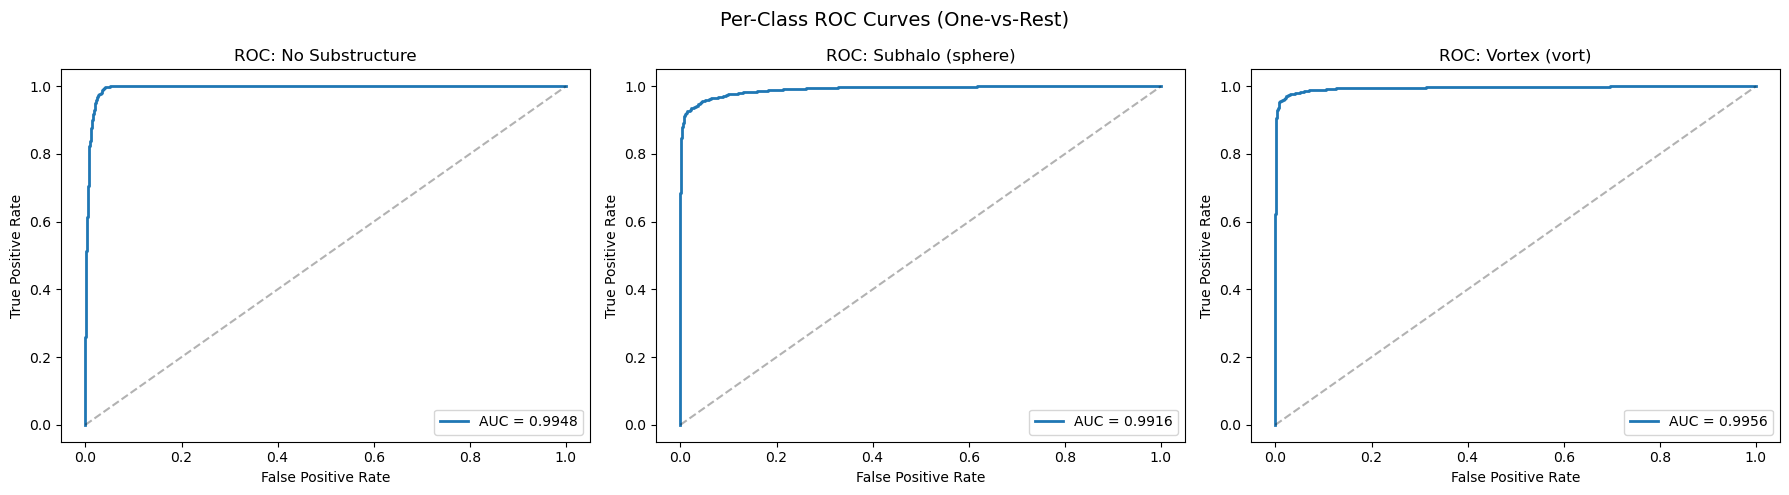


=== AUC Scores ===
  No Substructure: 0.9948
  Subhalo (sphere): 0.9916
  Vortex (vort): 0.9956
  Macro-averaged AUC: 0.9940

=== Classification Report ===
                  precision    recall  f1-score   support

 No Substructure       0.93      1.00      0.96      1250
Subhalo (sphere)       0.98      0.91      0.95      1250
   Vortex (vort)       0.97      0.96      0.97      1250

        accuracy                           0.96      3750
       macro avg       0.96      0.96      0.96      3750
    weighted avg       0.96      0.96      0.96      3750



In [5]:
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Get predictions on validation set using best saved model
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs)    # shape: (3750, 3)
all_labels = np.concatenate(all_labels)  # shape: (3750,)

# Per-class ROC curves (one-vs-rest)
class_names = ["No Substructure", "Subhalo (sphere)", "Vortex (vort)"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

auc_scores = {}
for i, cls_name in enumerate(class_names):
    binary_labels = (all_labels == i).astype(int)
    fpr, tpr, _ = roc_curve(binary_labels, all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    auc_scores[cls_name] = roc_auc
    
    axes[i].plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
    axes[i].plot([0, 1], [0, 1], "k--", alpha=0.3)
    axes[i].set_xlabel("False Positive Rate")
    axes[i].set_ylabel("True Positive Rate")
    axes[i].set_title(f"ROC: {cls_name}")
    axes[i].legend(loc="lower right")

plt.suptitle("Per-Class ROC Curves (One-vs-Rest)", fontsize=14)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary
macro_auc = np.mean(list(auc_scores.values()))
print("\n=== AUC Scores ===")
for cls_name, score in auc_scores.items():
    print(f"  {cls_name}: {score:.4f}")
print(f"  Macro-averaged AUC: {macro_auc:.4f}")

# Classification report
preds = all_probs.argmax(axis=1)
print("\n=== Classification Report ===")
print(classification_report(all_labels, preds, target_names=class_names))